# Agent Evaluation in Habitat with Observation Visualization

This notebook runs an evaluation loop for a visual language model (VLM) agent in the Habitat environment. The key features are:
- **Loading a pre-trained Qwen-VL model.**
- **Setting up the Habitat simulation environment.**
- **Running an evaluation loop where the agent takes actions based on visual input and a text prompt.**
- **Visualizing the agent's visual observation (`obs`) at each step.**

## 1. Imports

First, we import all the necessary libraries. We've added `IPython.display` to help visualize the images directly in the notebook.

In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "1"
import random
from functools import partial
from typing import Dict, List

import requests
import torch
from PIL import Image
from torchvision import io
from transformers import (AutoProcessor, Qwen2VLForConditionalGeneration,
                          Qwen2_5_VLForConditionalGeneration)

# For visualization in the notebook
from IPython.display import display, clear_output

# --- Custom Module Imports ---
# Note: Ensure these modules are in your Python path or the same directory.
import sys
sys.path.append("/data/tct/verl-agent/agent_system/environments/env_package/habitat_sim")
from utils.habitat_envs import CreateHabitatEnv
from agent_system.environments.prompts import HABITAT_VISUAL_GROUNDING_COT_TEMPLATE
from agent_system.multi_turn_rollout.utils import process_image

/data/tct/miniconda3/envs/verl-habitat/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/data/tct/miniconda3/envs/verl-habitat/lib/python3.10/site-packages/torch/cuda/__init__.py:129: UserWarning: CUDA initialization: CUDA driver initialization failed, you might not have a CUDA gpu. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:109.)
  return torch._C._cuda_getDeviceCount() > 0
2025-09-06 09:47:53,439	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


KeyboardInterrupt: 

## 2. Helper Functions

These are the core functions for model loading, inference, and processing environment data. They are adapted from your original script.

In [3]:
def habitat_projection(text_actions: List[str], env_name: str) -> (List[int], List[int]):
    """Projects the model's free-form text output to a discrete action index."""
    output_indices = []
    valids = []
    if env_name == 'habitat':
        action_list = ["move_forward", "turn_left", "turn_right", "look_up", "look_down", "stop"]
    elif env_name == 'gym_cards/NumberLine-v0':
        action_list = ["-", "+"]
    elif env_name == 'gym_cards/Blackjack-v0':
        action_list = ["stand", "hit"]
    elif env_name == 'gym_cards/EZPoints-v0':
        action_list = ["1", "2", "3", "4", "5", "6", "7", "8", "9", "10",
                       "+", "*", "="]
    elif env_name == 'gym_cards/Points24-v0':
        action_list = ["1", "2", "3", "4", "5", "6", "7", "8", "9", "10",
                       "+", "-", "*", "/", "(", ")", "="]
    else:
        raise NotImplementedError(f"Action list not implemented for this env: {env_name}!")
    
    for string in text_actions:
        if not isinstance(string, str):
            output_indices.append(random.randint(0, len(action_list) - 1))
            valids.append(0)
            continue
        
        string = string.lower()
        action_index = string.find('"action":')
        string = string[action_index:]
        contained_actions = []
        
        if 'points' in env_name.lower() and '10' in string:
            contained_actions.append('10')
            string = string.replace('10', '')
            
        for action in action_list:
            if action in string:
                contained_actions.append(action)
        
        contained_actions = list(set(contained_actions))
        
        if len(contained_actions) == 1 and contained_actions[0] in action_list:
            output_indices.append(action_list.index(contained_actions[0]))
            valids.append(1)
        else:
            output_indices.append(random.randint(0, len(action_list) - 1))
            valids.append(0)
            
    return output_indices, valids

In [4]:
def load_model_and_processor(model_path: str):
    """Loads the Qwen-VL model and its associated processor."""
    os.environ["CUDA_VISIBLE_DEVICES"] = "2"
    if "Qwen2.5" in model_path:
        print("Loading Qwen2.5-VL model from", model_path)
        model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
            model_path, 
            torch_dtype=torch.bfloat16, 
            attn_implementation="flash_attention_2",
            device_map="auto"
        )
    elif "Qwen2" in model_path:
        print("Loading Qwen2-VL model from", model_path)
        model = Qwen2VLForConditionalGeneration.from_pretrained(
            model_path, 
            torch_dtype=torch.bfloat16, 
            attn_implementation="flash_attention_2",
            device_map="auto"
        )
    else:
        raise ValueError("Unsupported model path. Please provide a valid Qwen2 or Qwen2.5 model path.")
    
    processor = AutoProcessor.from_pretrained(model_path)
    return model, processor

In [5]:
def inference(model, processor, image: Image.Image, prompt: str, max_new_tokens: int = 1024) -> str:
    """Performs inference with the model given an image and a text prompt."""
    messages = [{"role": "user", "content": prompt}]
    text_prompt = processor.apply_chat_template(messages, add_generation_prompt=True, tokenize=False)
    
    inputs = processor(
        text=[text_prompt], images=[image], padding=True, return_tensors="pt"
    ).to(model.device)
    
    output_ids = model.generate(**inputs, max_new_tokens=max_new_tokens)
    generated_ids = [
        output_ids[len(input_ids):]
        for input_ids, output_ids in zip(inputs.input_ids, output_ids)
    ]
    
    output_text = processor.batch_decode(
        generated_ids, skip_special_tokens=True, clean_up_tokenization_spaces=True
    )
    
    return output_text if output_text else ""

In [6]:
def get_scene_path(subfolders, dataset_name, eval_id=0):
    """Constructs the full path to a habitat scene file."""
    data_path = "/data/tct/habitat/data" # <-- Note: Hardcoded path
    if dataset_name == "HM3D":
        dataset_path = os.path.join(data_path, "hm3d")
        scene = subfolders[eval_id % len(subfolders)]
        id = scene.split('/')[1].split('-')[1]
        scene_path = f"{scene}/{id}.basis.glb"
        scene_id = os.path.join(dataset_path, scene_path)
    elif dataset_name == "ReplicaCAD":
        scene_name = subfolders[eval_id % len(subfolders)]
        scene_id = os.path.join(data_path, "replica_cad/configs/scenes", scene_name)
    else:
        raise ValueError(f"Unsupported dataset name: {dataset_name}")
    return scene_id

In [7]:
def build_text_obs(infos: List[Dict]) -> List[str]:
    """Builds the text observation (prompt) for the agent."""
    postprocess_text_obs = []
    for i in range(len(infos)):
        prompt = HABITAT_VISUAL_GROUNDING_COT_TEMPLATE.format(
            task_caption=infos[i]['task_prompt'],
            conf_score=infos[i]['conf_score']
        )
        postprocess_text_obs.append(prompt)
    return postprocess_text_obs

## 3. Setup and Configuration

Here, we define the configuration parameters for the evaluation, such as the model path and environment settings. Then, we load the model and processor.

In [8]:
# --- Configuration ---
# model_path = "/data/tct/verl-agent/checkpoints/verl_agent_habitat_test/grpo_qwen2_vl_2b-230-test-bs_8-4cards/Qwen2-VL-2B-HM3D-10"
# model_path = "/data/tct/LLaMA-Factory/output/Qwen2-VL-2B-replica10-vg-sft-test"
model_path = "/data/tct/verl-agent/checkpoints/verl_agent_habitat_test/sft_grpo_qwen2_vl_2b-230-replica-bs_8-4cards/global_step_100/Qwen2-VL-2B-sft-grpo"
# model_path = "/data/tct/models/Qwen2-VL-2B-Instruct"
# dataset_name = "HM3D"
dataset_name = "ReplicaCAD"
seed = 0
scenes_size = 10
max_scene_instance = 10
max_step_length = 10

# --- Load Model and Processor ---
# os.environ["CUDA_VISIBLE_DEVICES"] = "2"
model, processor = load_model_and_processor(model_path)
print("Model and processor loaded successfully.")

Loading Qwen2-VL model from /data/tct/verl-agent/checkpoints/verl_agent_habitat_test/sft_grpo_qwen2_vl_2b-230-replica-bs_8-4cards/global_step_100/Qwen2-VL-2B-sft-grpo


ValueError: FlashAttention2 has been toggled on, but it cannot be used due to the following error: Flash Attention 2 is not available on CPU. Please make sure torch can access a CUDA device.

## 4. Initialize Environment

Create an instance of the Habitat environment and the action projection function.

In [8]:
env = CreateHabitatEnv(seed, dataset_name, scenes_size, max_scene_instance, max_step_length)
projection_f = partial(habitat_projection, env_name='habitat')
print("Habitat environment created.")

Habitat environment created.


## 5. Run Evaluation with Visualization

This is the main evaluation loop. At each step, it will:
1. Get the current observation (`obs`) from the environment.
2. **Clear the previous output and display the new `obs` image.**
3. Build the prompt for the model.
4. Get the model's text action.
5. Convert the text action to a valid environment action.
6. Take the step in the environment.
7. Repeat until the episode is done or the max steps are reached.

TASK 1/500 | STEP 1/10
Task: Indoor Plant


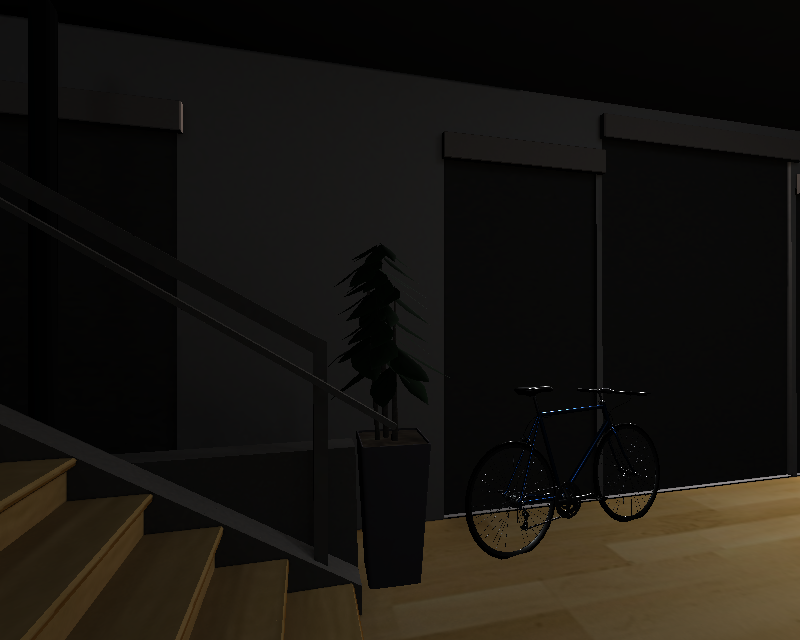

Processing Tasks:   0%|          | 0/500 [01:26<?, ?it/s]


KeyboardInterrupt: 

In [12]:
import time
import base64
import io
from PIL import Image
import numpy as np
import json
from tqdm import tqdm

# 假设这些函数和变量已经定义在别处
# from some_module import inference, process_image, build_text_obs, projection_f, clear_output, display, env, model, processor
# max_step_length = 50 

# --- 1. 辅助函数 (无需修改) ---

def image_to_base64_str(obs):
    """将图像（NumPy数组或PIL图像）转换为Base64编码的字符串"""
    if not isinstance(obs, Image.Image):
        img = Image.fromarray(obs)
    else:
        img = obs
    
    buffer = io.BytesIO()
    img.save(buffer, format="PNG")
    
    img_bytes = buffer.getvalue()
    base64_str = base64.b64encode(img_bytes).decode('utf-8')
    
    return f"data:image/png;base64,{base64_str}"

def reshape_bbox(bbox, original_size=(1000, 800), new_size=(800, 640)):
    """
    (针对GroundingDINO的输出) 根据图像尺寸变化对bbox进行转换。

    参数:
        bbox (tuple): 原始bbox，格式为 (x1, y1, x2, y2)。
        original_size (tuple): 原始图像尺寸 (宽, 高)。
        new_size (tuple): 新图像尺寸 (宽, 高)。

    返回:
        tuple: 转换后的bbox，格式为 (x1, y1, x2, y2)。
    """
    if bbox is None:
        return (0, 0, 0, 0) # 如果bbox不存在，返回一个默认值避免错误
    scale_x = new_size[0] / original_size[0]
    scale_y = new_size[1] / original_size[1]
    x1, y1, x2, y2 = bbox
    x1_new = x1 * scale_x
    y1_new = y1 * scale_y
    x2_new = x2 * scale_x
    y2_new = y2 * scale_y
    return (x1_new, y1_new, x2_new, y2_new)

def calculate_iou(box2_gt, box1_pred):
    """
    计算两个边界框的IoU。
    
    Args:
        box2_gt (list or tuple): ground truth, 格式为 [xmin, ymin, xmax, ymax]。
        box1_pred (list or tuple): 预测的边界框, 格式为 xyxy。

    Returns:
        float: IoU 值。
    """
    # 如果任何一个box是None，无法计算IoU，返回0
    if box1_pred is None or box2_gt is None:
        return 0.0

    # 调整预测框尺寸并确保格式正确
    box1 = reshape_bbox(box1_pred) # box1 is now (x1, y1, x2, y2)
    
    # 确保GT的box格式为 (x1, y1, x2, y2)
    box2 = (box2_gt[0], box2_gt[2], box2_gt[1], box2_gt[3])

    x1_inter = max(box1[0], box2[0])
    y1_inter = max(box1[1], box2[1])
    x2_inter = min(box1[2], box2[2])
    y2_inter = min(box1[3], box2[3])

    intersection_width = max(0, x2_inter - x1_inter)
    intersection_height = max(0, y2_inter - y1_inter)
    intersection_area = intersection_width * intersection_height

    box1_area = (box1[2] - box1[0]) * (box1[3] - box1[1])
    box2_area = (box2[2] - box2[0]) * (box2[3] - box2[1])

    union_area = box1_area + box2_area - intersection_area
    iou = intersection_area / union_area if union_area > 0 else 0
    return iou


# --- 2. 修改主逻辑 ---

# 初始化列表用于存储评估指标和日志
html_log_entries = []
all_initial_ious = []
all_final_ious = []
all_initial_confs = []
all_final_confs = []

# 定义日志和输入文件名
log_filename = "evaluation_logs/eval_data-IoU-sft-grpo-100-0_evaluation_cad_log.html"
input_filename = '/data/tct/habitat/eval_data/replica_cad_eval_data/task_infos.json'

# 加载任务信息
try:
    with open(input_filename, 'r', encoding='utf-8') as f:
        all_task_infos = json.load(f)
    print(f"成功从 {input_filename} 中加载了 {len(all_task_infos)} 条任务信息。\n")
except FileNotFoundError:
    print(f"错误：找不到输入文件 {input_filename}。")
    all_task_infos = [] # 确保后续代码不会因 all_task_infos 未定义而崩溃

# ----------------- 主循环开始 -----------------
total_tasks = len(all_task_infos)
# 【修改】使用 enumerate 直接遍历任务信息列表，并获取索引和内容
for idx, task_info in enumerate(tqdm(all_task_infos, desc="Processing Tasks")):
    obs, info = env.reset_eval(sync_info=task_info)
    
    # --- 计算初始 IoU 和 Conf ---
    initial_iou = calculate_iou(info.get("bbox_gt"), info.get("bbox_vg"))
    initial_conf = info.get("conf_score", 0.0)
    all_initial_ious.append(initial_iou)
    all_initial_confs.append(initial_conf)
    
    # 【修改】更新打印内容，使用新的循环变量
    print(f"\n--- Starting new episode: Task {idx+1}/{total_tasks} ---")
    print(f"Scene Path: {info.get('scene_id', 'N/A')}")
    print(f"Task Prompt: {info.get('task_prompt', 'N/A')}")
    print(f"Initial IoU: {initial_iou:.4f} | Initial Conf: {initial_conf:.4f}")
    
    # 【修改】为每个 episode 添加一个标题到HTML日志中
    episode_header_html = f"""
    <h2>--- Episode Start: Task {idx+1}/{total_tasks} (Scene: {info.get('scene_id', 'N/A')}) ---</h2>
    <p><b>Task Prompt:</b> {info.get('task_prompt', 'N/A')}</p>
    <p><b>Initial IoU:</b> {initial_iou:.4f} | <b>Initial Conf:</b> {initial_conf:.4f}</p>
    """
    html_log_entries.append(episode_header_html)
    
    done = False
    for k in range(max_step_length):
        clear_output(wait=True)

        # 【修改】更新打印内容
        print(f"TASK {idx+1}/{total_tasks} | STEP {k+1}/{max_step_length}")
        print(f"Task: {info['task_prompt']}")
        display(obs)
        
        prompt = build_text_obs([info])[0].replace('<image>', '<|vision_start|><|image_pad|><|vision_end|>')
        
        text_actions = inference(model, processor, process_image(obs), prompt)
        actions, valids = projection_f(text_actions, env_name="habitat")
        action_name = env.action_space[actions[0]]
        
        print(f"\nModel Output: {text_actions[0]}")
        print(f"Predicted Action: '{action_name}' (Valid: {bool(valids[0])})")

        # 创建当前步骤的HTML内容 (无需修改)
        base64_image = image_to_base64_str(obs)
        step_html = f"""
        <div class="step-container">
            <h3>STEP {k+1}/{max_step_length}</h3>
            <p><b>Task:</b> {info['task_prompt']}</p>
            <img src="{base64_image}" alt="Agent view at step {k+1}" class="agent-view">
            <div class="model-output">
                <p><b>Model Output:</b> <code>{text_actions[0]}</code></p>
                <p><b>Predicted Action:</b> '{action_name}' (Valid: {bool(valids[0])})</p>
            </div>
        </div>
        """
        html_log_entries.append(step_html)
        
        obs, reward, done, info = env.step(actions[0], valids[0])

        if done:
            break
    
    # --- 计算最终 IoU 和 Conf ---
    final_iou = calculate_iou(info.get("bbox_gt"), info.get("bbox_vg"))
    final_conf = info.get("conf_score", 0.0)
    all_final_ious.append(final_iou)
    all_final_confs.append(final_conf)

    # 记录结束信息 (无需修改)
    if done:
        print(f"\n--- Episode finished at step {k+1} with reward {reward} ---")
        print(f"Final IoU: {final_iou:.4f} | Final Conf: {final_conf:.4f}")
        finish_html = f"<p class='finish-message'><b>--- Episode finished at step {k+1} with reward {reward}. Final IoU: {final_iou:.4f} | Final Conf: {final_conf:.4f} ---</b></p>"
    else:
        print(f"\n--- Episode timed out at step {k+1} ---")
        print(f"Final IoU: {final_iou:.4f} | Final Conf: {final_conf:.4f}")
        finish_html = f"<p class='timeout-message'><b>--- Episode timed out at step {k+1}. Final IoU: {final_iou:.4f} | Final Conf: {final_conf:.4f} ---</b></p>"
        
    html_log_entries.append(finish_html)

print("\nEvaluation loop completed.")


# --- 4. 计算平均值并生成HTML文件 (无需修改) ---

# 计算IoU和Conf的平均值
avg_initial_iou = np.mean(all_initial_ious) if all_initial_ious else 0.0
avg_final_iou = np.mean(all_final_ious) if all_final_ious else 0.0
avg_initial_conf = np.mean(all_initial_confs) if all_initial_confs else 0.0
avg_final_conf = np.mean(all_final_confs) if all_final_confs else 0.0

# 计算提升百分比
def calculate_improvement(initial, final):
    if initial > 0:
        percent = ((final - initial) / initial) * 100
        return f"{percent:+.2f}%"
    return "N/A (初始值为0)"

iou_improvement_str = calculate_improvement(avg_initial_iou, avg_final_iou)
conf_improvement_str = calculate_improvement(avg_initial_conf, avg_final_conf)

print("\n--- Evaluation Summary ---")
print(f"Average Initial IoU:    {avg_initial_iou:.4f}")
print(f"Average Final IoU:      {avg_final_iou:.4f} ({iou_improvement_str})")
print(f"Average Initial Conf:   {avg_initial_conf:.4f}")
print(f"Average Final Conf:     {avg_final_conf:.4f} ({conf_improvement_str})")

# 为HTML报告中的百分比添加颜色
def get_colored_html_percent(percent_str):
    if percent_str.startswith('+'):
        return f'<span style="color: green; font-weight: bold;">{percent_str}</span>'
    elif percent_str.startswith('-'):
        return f'<span style="color: red; font-weight: bold;">{percent_str}</span>'
    else:
        return f'<span>{percent_str}</span>'

iou_improvement_html = get_colored_html_percent(iou_improvement_str)
conf_improvement_html = get_colored_html_percent(conf_improvement_str)

# 创建HTML摘要块
summary_html = f"""
<div class="summary-container">
    <h2>Evaluation Summary</h2>
    <p><b>Total Tasks Evaluated:</b> {total_tasks}</p>
    <p><b>Average Initial IoU:</b> {avg_initial_iou:.4f}</p>
    <p><b>Average Final IoU:</b> {avg_final_iou:.4f}</p>
    <p><b>IoU Improvement:</b> {iou_improvement_html}</p>
    <hr style="border-top: 1px dashed #ccc; margin: 10px 0;">
    <p><b>Average Initial Conf:</b> {avg_initial_conf:.4f}</p>
    <p><b>Average Final Conf:</b> {avg_final_conf:.4f}</p>
    <p><b>Conf Improvement:</b> {conf_improvement_html}</p>
</div>
<hr>
"""

# 定义HTML的头部
html_header = f"""
<!DOCTYPE html>
<html lang="zh-CN">
<head>
    <meta charset="UTF-8">
    <title>Evaluation Log</title>
    <style>
        body {{ font-family: -apple-system, BlinkMacSystemFont, "Segoe UI", Roboto, "Helvetica Neue", Arial, sans-serif; margin: 20px; line-height: 1.6; color: #333; }}
        h1 {{ color: #1a237e; }}
        h2 {{ color: #2c3e50; border-bottom: 2px solid #3498db; padding-bottom: 10px; margin-top: 40px; }}
        h3 {{ color: #34495e; }}
        .summary-container {{ background-color: #e3f2fd; border: 2px solid #90caf9; padding: 20px; margin-bottom: 20px; border-radius: 8px; }}
        .step-container {{ border: 1px solid #ccc; padding: 15px; margin-bottom: 20px; border-radius: 8px; background-color: #f9f9f9; box-shadow: 0 2px 4px rgba(0,0,0,0.1); }}
        .agent-view {{ max-width: 480px; height: auto; border: 1px solid #ddd; border-radius: 4px; display: block; margin-top: 10px; }}
        .model-output {{ background-color: #ecf0f1; padding: 10px; border-radius: 5px; margin-top: 10px; }}
        code {{ background-color: #e0e0e0; padding: 2px 5px; border-radius: 3px; font-family: 'Courier New', Courier, monospace; }}
        .finish-message {{ font-weight: bold; color: #27ae60; background-color: #e8f5e9; padding: 10px; border-radius: 5px; }}
        .timeout-message {{ font-weight: bold; color: #e67e22; background-color: #fff3e0; padding: 10px; border-radius: 5px; }}
    </style>
</head>
<body>
    <h1>Evaluation Log - {time.strftime('%Y-%m-%d %H:%M:%S')}</h1>
"""

# 定义HTML的尾部
html_footer = """
</body>
</html>
"""

# 拼接并写入完整的HTML文件
full_html_content = html_header + summary_html + "\n".join(html_log_entries) + html_footer
with open(log_filename, 'w', encoding='utf-8') as f:
    f.write(full_html_content)

print(f"\n✅ Log successfully saved to '{log_filename}'")


SCENE 10/10 | INSTANCE 3/3 | STEP 1/10
Task: Television screen on wall


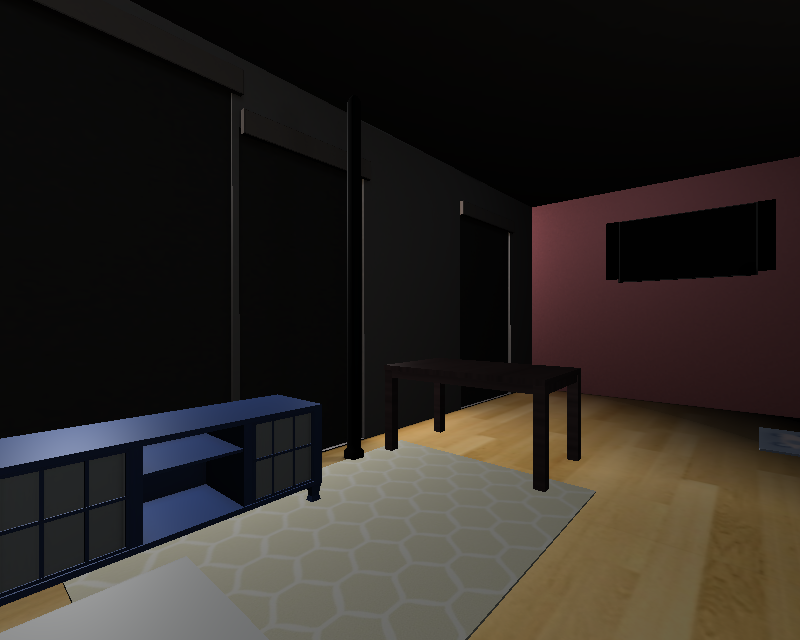


Model Output: {
"thoughts": "The object is in the center of the image. The object appears to be at an observation score of 0.729. To better observe the target object, I should choose action "stop" from the json file. ", 
"action": "stop" 
}
Predicted Action: 'stop' (Valid: True)

--- Episode finished at step 1 with reward 0.05 ---

Evaluation loop completed.

✅ Log successfully saved to 'evaluation_logs/sft-grpo-100_evaluation_cad_log.html'


In [9]:
import time
import base64
import io
from PIL import Image

# --- 1. 新增的辅助函数 ---
# 这个函数负责将图像数据（obs）转换成可以直接嵌入HTML的Base64字符串
def image_to_base64_str(obs):
    """将图像（NumPy数组或PIL图像）转换为Base64编码的字符串"""
    # 如果 obs 是 NumPy 数组, 将其转换为 PIL 图像
    if not isinstance(obs, Image.Image):
        # 假设 obs 是一个 HWC (Height, Width, Channel) 格式的 NumPy 数组
        img = Image.fromarray(obs)
    else:
        img = obs
    
    # 将图像保存到一个内存中的二进制流（buffer）中
    buffer = io.BytesIO()
    img.save(buffer, format="PNG") # 你也可以用 "JPEG"
    
    # 从 buffer 中获取二进制数据，并进行Base64编码
    img_bytes = buffer.getvalue()
    base64_str = base64.b64encode(img_bytes).decode('utf-8')
    
    return f"data:image/png;base64,{base64_str}"

# --- 2. 修改主逻辑 ---

# 在循环开始前，初始化一个列表来存储所有HTML日志条目
html_log_entries = []

# 定义日志文件名
log_filename = "evaluation_logs/sft-grpo-100_evaluation_cad_log.html"

# ----------------- 主循环开始 -----------------
for i in range(scenes_size):
    special_scene_id = get_scene_path(env.scene_subfolder, dataset_name, eval_id=i) # 恢复这行
    for j in range(max_scene_instance):
        obs, info = env.reset(seed=seed, is_unique=True, sync_info=None, special_scene_id=special_scene_id) # 恢复这行
        
        print(f"--- Starting new episode: Scene {i+1}/{scenes_size}, Instance {j+1}/{max_scene_instance} ---")
        print(f"Scene Path: {info['scene_id']}")
        
        # 为每个 episode 添加一个标题到HTML日志中
        episode_header_html = f"<h2>--- Episode Start: Scene {i+1}/{scenes_size}, Instance {j+1}/{max_scene_instance} ---</h2>"
        html_log_entries.append(episode_header_html)
        
        for k in range(max_step_length):
            clear_output(wait=True)
    
            # 仍然在控制台打印实时进度，方便观察
            print(f"SCENE {i+1}/{scenes_size} | INSTANCE {j+1}/{max_scene_instance} | STEP {k+1}/{max_step_length}")
            print(f"Task: {info['task_prompt']}")
            display(obs)
            
            # Prepare prompt for the model
            prompt = build_text_obs([info])[0].replace('<image>', '<|vision_start|><|image_pad|><|vision_end|>')
            
            # Get action from the model
            text_actions = inference(model, processor, process_image(obs), prompt)
            actions, valids = projection_f(text_actions, env_name="habitat")
            action_name = env.action_space[actions[0]]
            
            print(f"\nModel Output: {text_actions[0]}")
            print(f"Predicted Action: '{action_name}' (Valid: {bool(valids[0])})")

            # --- 3. 创建当前步骤的HTML内容 ---
            # 将图像转换为Base64字符串
            base64_image = image_to_base64_str(obs)
            
            # 构建HTML代码块
            step_html = f"""
            <div class="step-container">
                <h3>STEP {k+1}/{max_step_length}</h3>
                <p><b>Task:</b> {info['task_prompt']}</p>
                <img src="{base64_image}" alt="Agent view at step {k+1}" class="agent-view">
                <div class="model-output">
                    <p><b>Model Output:</b> <code>{text_actions[0]}</code></p>
                    <p><b>Predicted Action:</b> '{action_name}' (Valid: {bool(valids[0])})</p>
                </div>
            </div>
            """
            # 将这个步骤的HTML添加到日志列表中
            html_log_entries.append(step_html)

            time.sleep(0.1) # 缩短演示时的等待时间
            
            # Take a step in the environment
            obs, reward, done, info = env.step(actions[0], valids[0])

            if done:
                print(f"\n--- Episode finished at step {k+1} with reward {reward} ---")
                
                # 在HTML日志中记录结束信息
                finish_html = f"<p class='finish-message'><b>--- Episode finished at step {k+1} with reward {reward} ---</b></p>"
                html_log_entries.append(finish_html)
                
                time.sleep(0.5) # 缩短演示时的等待时间
                break

print("\nEvaluation loop completed.")

# --- 4. 在所有循环结束后，生成并保存HTML文件 ---
# 定义HTML的头部，包含一些简单的CSS样式，让日志更美观
html_header = f"""
<!DOCTYPE html>
<html lang="zh-CN">
<head>
    <meta charset="UTF-8">
    <title>Evaluation Log</title>
    <style>
        body {{ font-family: sans-serif; margin: 20px; }}
        h2 {{ color: #2c3e50; border-bottom: 2px solid #3498db; padding-bottom: 10px; }}
        h3 {{ color: #34495e; }}
        .step-container {{ border: 1px solid #ccc; padding: 15px; margin-bottom: 20px; border-radius: 8px; background-color: #f9f9f9; }}
        .agent-view {{ max-width: 480px; border: 1px solid #ddd; border-radius: 4px; }}
        .model-output {{ background-color: #ecf0f1; padding: 10px; border-radius: 5px; margin-top: 10px; }}
        code {{ background-color: #e0e0e0; padding: 2px 5px; border-radius: 3px; font-family: monospace; }}
        .finish-message {{ font-weight: bold; color: #27ae60; }}
    </style>
</head>
<body>
    <h1>Evaluation Log - {time.strftime('%Y-%m-%d %H:%M:%S')}</h1>
"""

# 定义HTML的尾部
html_footer = """
</body>
</html>
"""

# 将所有HTML片段拼接成一个完整的HTML文件
full_html_content = html_header + "\n".join(html_log_entries) + html_footer

# 写入文件
with open(log_filename, 'w', encoding='utf-8') as f:
    f.write(full_html_content)

print(f"\n✅ Log successfully saved to '{log_filename}'")

SCENE 1/10 | INSTANCE 4/10 | STEP 4/10
Task: chair near bookshelf


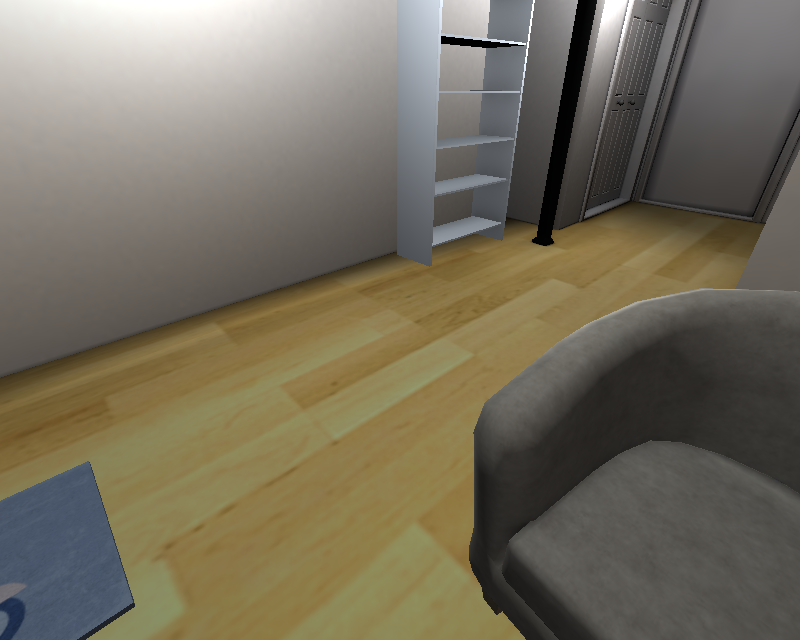

In [ ]:
import time
import base64
import io
from PIL import Image
import numpy as np

# --- 1. 辅助函数 ---

def image_to_base64_str(obs):
    """将图像（NumPy数组或PIL图像）转换为Base64编码的字符串"""
    if not isinstance(obs, Image.Image):
        img = Image.fromarray(obs)
    else:
        img = obs
    
    buffer = io.BytesIO()
    img.save(buffer, format="PNG")
    
    img_bytes = buffer.getvalue()
    base64_str = base64.b64encode(img_bytes).decode('utf-8')
    
    return f"data:image/png;base64,{base64_str}"

def reshape_bbox(bbox, original_size=(1000, 800), new_size=(800, 640)):
    """
    (针对GroundingDINO的输出) 根据图像尺寸变化对bbox进行转换。

    参数:
        bbox (tuple): 原始bbox，格式为 (x1, y1, x2, y2)。
        original_size (tuple): 原始图像尺寸 (宽, 高)。
        new_size (tuple): 新图像尺寸 (宽, 高)。

    返回:
        tuple: 转换后的bbox，格式为 (x1, y1, x2, y2)。
    """
    # 计算宽度和高度的缩放比例
    scale_x = new_size[0] / original_size[0]
    scale_y = new_size[1] / original_size[1]

    # 对bbox的坐标进行缩放
    x1, y1, x2, y2 = bbox
    x1_new = x1 * scale_x
    y1_new = y1 * scale_y
    x2_new = x2 * scale_x
    y2_new = y2 * scale_y

    return (x1_new, y1_new, x2_new, y2_new)

def calculate_iou(box2, box1):
    """
    bbox: 预测的边界框，格式为 xyxy, 但是需要reshape
    bbox_gt: ground truth bounding box, 格式为 [xmin, xmax, ymin, ymax]
    計算兩個邊界框（bounding box）的 IoU (Intersection over Union)。

    Args:
        box1 (list or tuple): 第一個邊界框，格式為 [x1, y1, x2, y2]。
        box2 (list or tuple): 第二個邊界框，格式為 [x1, y1, x2, y2]。

    Returns:
        float: IoU 值，範圍在 0.0 到 1.0 之間。
    """
    # 调整输入格式
    box1 = reshape_bbox(box1)  
    box_tmp = [box2[0], box2[2], box2[1], box2[3]]
    box2 = box_tmp
    # 獲取交集矩形的座標
    x1_inter = max(box1[0], box2[0])
    y1_inter = max(box1[1], box2[1])
    x2_inter = min(box1[2], box2[2])
    y2_inter = min(box1[3], box2[3])

    # 計算交集區域的面積
    # 如果 x2_inter < x1_inter 或 y2_inter < y1_inter，表示沒有交集，面積為 0
    intersection_width = max(0, x2_inter - x1_inter)
    intersection_height = max(0, y2_inter - y1_inter)
    intersection_area = intersection_width * intersection_height

    # 計算兩個邊界框各自的面積
    box1_area = (box1[2] - box1[0]) * (box1[3] - box1[1])
    box2_area = (box2[2] - box2[0]) * (box2[3] - box2[1])

    # 計算聯集（Union）的面積
    union_area = box1_area + box2_area - intersection_area

    # 計算 IoU
    # 處理聯集面積為 0 的情況（例如兩個 box 面積都為 0）
    iou = intersection_area / union_area if union_area > 0 else 0

    return iou

# def calculate_iou(boxA, boxB):
#     """
#     计算两个边界框之间的交并比（IoU）。
#     期望的格式是 [x_min, y_min, x_max, y_max].
#     """
#     if boxA is None or boxB is None or len(boxA) != 4 or len(boxB) != 4:
#         return 0.0

#     xA = max(boxA[0], boxB[0])
#     yA = max(boxA[1], boxB[1])
#     xB = min(boxA[2], boxB[2])
#     yB = min(boxA[3], boxB[3])

#     interArea = max(0, xB - xA) * max(0, yB - yA)
#     boxAArea = (boxA[2] - boxA[0]) * (boxA[3] - boxA[1])
#     boxBArea = (boxB[2] - boxB[0]) * (boxB[3] - boxB[1])
#     unionArea = float(boxAArea + boxBArea - interArea)
#     iou = interArea / unionArea if unionArea > 0 else 0.0
    
#     return iou

# --- 2. 修改主逻辑 ---

# 在循环开始前，初始化一个列表来存储所有HTML日志条目和评估指标
html_log_entries = []
all_initial_ious = []
all_final_ious = []
all_initial_confs = []
all_final_confs = []

# 定义日志文件名
log_filename = "evaluation_logs/eval_data-IoU-sft-grpo-100-0_evaluation_cad_log.html"

# 定义要读取的JSON文件名
input_filename = '/data/tct/habitat/eval_data/replica_cad_eval_data/task_infos.json'
import json
with open(input_filename, 'r', encoding='utf-8') as f:
    all_task_infos = json.load(f)
print(f"成功从 {input_filename} 中加载了 {len(all_task_infos)} 条任务信息。\n")

# ----------------- 主循环开始 -----------------
from tqdm import tqdm
for task_info in tqdm(range(all_task_infos), desc="Processing Scenes"):
    obs, info = env.reset_eval(sync_info=task_info)  
    # --- 计算初始 IoU 和 Conf ---
    initial_iou = calculate_iou(info.get("bbox_gt"), info.get("bbox_vg"))
    initial_conf = info.get("conf_score", 0.0)
    all_initial_ious.append(initial_iou)
    all_initial_confs.append(initial_conf)
    
    print(f"--- Starting new episode: Scene {i+1}/{scenes_size}, Instance {j+1}/{max_scene_instance} ---")
    print(f"Scene Path: {info['scene_id']}")
    print(f"Initial IoU: {initial_iou:.4f} | Initial Conf: {initial_conf:.4f}")
    
    # 为每个 episode 添加一个标题到HTML日志中，包含初始IoU和Conf
    episode_header_html = f"""
    <h2>--- Episode Start: Scene {i+1}/{scenes_size}, Instance {j+1}/{max_scene_instance} ---</h2>
    <p><b>Initial IoU:</b> {initial_iou:.4f} | <b>Initial Conf:</b> {initial_conf:.4f}</p>
    """
    html_log_entries.append(episode_header_html)
    
    done = False
    for k in range(max_step_length):
        clear_output(wait=True)

        print(f"SCENE {i+1}/{scenes_size} | INSTANCE {j+1}/{max_scene_instance} | STEP {k+1}/{max_step_length}")
        print(f"Task: {info['task_prompt']}")
        display(obs)
        
        prompt = build_text_obs([info])[0].replace('<image>', '<|vision_start|><|image_pad|><|vision_end|>')
        
        text_actions = inference(model, processor, process_image(obs), prompt)
        actions, valids = projection_f(text_actions, env_name="habitat")
        action_name = env.action_space[actions[0]]
        
        print(f"\nModel Output: {text_actions[0]}")
        print(f"Predicted Action: '{action_name}' (Valid: {bool(valids[0])})")

        # 创建当前步骤的HTML内容
        base64_image = image_to_base64_str(obs)
        step_html = f"""
        <div class="step-container">
            <h3>STEP {k+1}/{max_step_length}</h3>
            <p><b>Task:</b> {info['task_prompt']}</p>
            <img src="{base64_image}" alt="Agent view at step {k+1}" class="agent-view">
            <div class="model-output">
                <p><b>Model Output:</b> <code>{text_actions[0]}</code></p>
                <p><b>Predicted Action:</b> '{action_name}' (Valid: {bool(valids[0])})</p>
            </div>
        </div>
        """
        html_log_entries.append(step_html)
        
        obs, reward, done, info = env.step(actions[0], valids[0])

        if done:
            break
    
    # --- 计算最终 IoU 和 Conf (在episode循环结束后) ---
    final_iou = calculate_iou(info.get("bbox_gt"), info.get("bbox_vg"))
    final_conf = info.get("conf_score", 0.0)
    all_final_ious.append(final_iou)
    all_final_confs.append(final_conf)

    if done:
        print(f"\n--- Episode finished at step {k+1} with reward {reward} ---")
        print(f"Final IoU: {final_iou:.4f} | Final Conf: {final_conf:.4f}")
        finish_html = f"<p class='finish-message'><b>--- Episode finished at step {k+1} with reward {reward}. Final IoU: {final_iou:.4f} | Final Conf: {final_conf:.4f} ---</b></p>"
    else: # Episode因达到max_step_length而结束
        print(f"\n--- Episode timed out at step {k+1} ---")
        print(f"Final IoU: {final_iou:.4f} | Final Conf: {final_conf:.4f}")
        finish_html = f"<p class='timeout-message'><b>--- Episode timed out at step {k+1}. Final IoU: {final_iou:.4f} | Final Conf: {final_conf:.4f} ---</b></p>"
        
    html_log_entries.append(finish_html)

print("\nEvaluation loop completed.")

# --- 4. 在所有循环结束后，计算平均值并生成HTML文件 ---

# 计算IoU和Conf的平均值
avg_initial_iou = np.mean(all_initial_ious) if all_initial_ious else 0.0
avg_final_iou = np.mean(all_final_ious) if all_final_ious else 0.0
avg_initial_conf = np.mean(all_initial_confs) if all_initial_confs else 0.0
avg_final_conf = np.mean(all_final_confs) if all_final_confs else 0.0

# --- 新增：计算提升百分比 ---
if avg_initial_iou > 0:
    iou_improvement_percent = ((avg_final_iou - avg_initial_iou) / avg_initial_iou) * 100
    iou_improvement_str = f"{iou_improvement_percent:+.2f}%"
else:
    iou_improvement_str = "N/A (初始值为0)"

if avg_initial_conf > 0:
    conf_improvement_percent = ((avg_final_conf - avg_initial_conf) / avg_initial_conf) * 100
    conf_improvement_str = f"{conf_improvement_percent:+.2f}%"
else:
    conf_improvement_str = "N/A (初始值为0)"
# --- 新增结束 ---

print("\n--- Evaluation Summary ---")
print(f"Average Initial IoU:    {avg_initial_iou:.4f}")
print(f"Average Final IoU:      {avg_final_iou:.4f}")
print(f"Average Initial Conf:   {avg_initial_conf:.4f}")
print(f"Average Final Conf:     {avg_final_conf:.4f}")
print(f"IoU Improvement:        {iou_improvement_str}")   # 新增
print(f"Conf Improvement:       {conf_improvement_str}")  # 新增

# --- 新增：为HTML报告中的百分比添加颜色 ---
def get_colored_html_percent(percent_str):
    if percent_str.startswith('+'):
        return f'<span style="color: green; font-weight: bold;">{percent_str}</span>'
    elif percent_str.startswith('-'):
        return f'<span style="color: red; font-weight: bold;">{percent_str}</span>'
    else: # 处理 "N/A" 或 "0.00%"
        return f'<span>{percent_str}</span>'

iou_improvement_html = get_colored_html_percent(iou_improvement_str)
conf_improvement_html = get_colored_html_percent(conf_improvement_str)
# --- 新增结束 ---


# 创建HTML摘要块
summary_html = f"""
<div class="summary-container">
    <h2>Evaluation Summary</h2>
    <p><b>Average Initial IoU:</b> {avg_initial_iou:.4f}</p>
    <p><b>Average Final IoU:</b> {avg_final_iou:.4f}</p>
    <p><b>IoU Improvement:</b> {iou_improvement_html}</p>
    <hr style="border-top: 1px dashed #ccc; margin: 10px 0;">
    <p><b>Average Initial Conf:</b> {avg_initial_conf:.4f}</p>
    <p><b>Average Final Conf:</b> {avg_final_conf:.4f}</p>
    <p><b>Conf Improvement:</b> {conf_improvement_html}</p>
</div>
<hr>
"""

# 定义HTML的头部，包含一些简单的CSS样式
html_header = f"""
<!DOCTYPE html>
<html lang="zh-CN">
<head>
    <meta charset="UTF-8">
    <title>Evaluation Log</title>
    <style>
        body {{ font-family: sans-serif; margin: 20px; }}
        h1 {{ color: #1a237e; }}
        h2 {{ color: #2c3e50; border-bottom: 2px solid #3498db; padding-bottom: 10px; }}
        h3 {{ color: #34495e; }}
        .summary-container {{ background-color: #e3f2fd; border: 2px solid #90caf9; padding: 15px; margin-bottom: 20px; border-radius: 8px; }}
        .step-container {{ border: 1px solid #ccc; padding: 15px; margin-bottom: 20px; border-radius: 8px; background-color: #f9f9f9; }}
        .agent-view {{ max-width: 480px; border: 1px solid #ddd; border-radius: 4px; }}
        .model-output {{ background-color: #ecf0f1; padding: 10px; border-radius: 5px; margin-top: 10px; }}
        code {{ background-color: #e0e0e0; padding: 2px 5px; border-radius: 3px; font-family: monospace; }}
        .finish-message {{ font-weight: bold; color: #27ae60; }}
        .timeout-message {{ font-weight: bold; color: #e67e22; }}
    </style>
</head>
<body>
    <h1>Evaluation Log - {time.strftime('%Y-%m-%d %H:%M:%S')}</h1>
"""

# 定义HTML的尾部
html_footer = """
</body>
</html>
"""

# 将所有HTML片段拼接成一个完整的HTML文件
full_html_content = html_header + summary_html + "\n".join(html_log_entries) + html_footer

# 写入文件
with open(log_filename, 'w', encoding='utf-8') as f:
    f.write(full_html_content)

print(f"\n✅ Log successfully saved to '{log_filename}'")

In [ ]:
import logging
import os
import time
from datetime import datetime
# 假設 clear_output 和 display 來自 IPython.display
from IPython.display import clear_output, display

# --- 1. 設定日誌與資料夾 (請將這段程式碼放在迴圈之前) ---

# 為這次評估運行創建一個帶有時間戳的唯一資料夾
run_timestamp = datetime.now().strftime('%Y-%m-%d_%H-%M-%S')
log_dir = f"evaluation_logs/{run_timestamp}"
os.makedirs(log_dir, exist_ok=True)

# 設定 logger
log_file_path = os.path.join(log_dir, "evaluation.log")
logger = logging.getLogger('evaluation_logger')
logger.setLevel(logging.INFO)

# 避免在 Jupyter Notebook 中重複運行儲存格時重複添加 handler
if not logger.handlers:
    # 檔案 handler：將日誌寫入檔案
    file_handler = logging.FileHandler(log_file_path)
    file_handler.setLevel(logging.INFO)

    # 終端機 handler：在螢幕上印出日誌
    console_handler = logging.StreamHandler()
    console_handler.setLevel(logging.INFO)

    # 設定日誌格式
    formatter = logging.Formatter('%(asctime)s - %(message)s', datefmt='%Y-%m-%d %H:%M:%S')
    file_handler.setFormatter(formatter)
    console_handler.setFormatter(formatter)

    # 將 handler 加入 logger
    logger.addHandler(file_handler)
    logger.addHandler(console_handler)

logger.info(f"日誌與圖像將儲存於：{os.path.abspath(log_dir)}")

# --- 2. 修改後的評估迴圈 ---

# 假設 scenes_size, max_scene_instance, env, model, processor, projection_f 等變數都已定義好

for i in range(scenes_size):
    special_scene_id = get_scene_path(env.scene_subfolder, dataset_name, eval_id=i)
    for j in range(max_scene_instance):
        # 為當前的 episode 創建一個專屬的圖像資料夾
        episode_img_dir = os.path.join(log_dir, f"scene_{i+1:02d}_instance_{j+1:02d}")
        os.makedirs(episode_img_dir, exist_ok=True)

        obs, info = env.reset(seed=seed, is_unique=True, sync_info=None, special_scene_id=special_scene_id)
        
        logger.info(f"--- 開始新回合: 場景 {i+1}/{scenes_size}, 實例 {j+1}/{max_scene_instance} ---")
        logger.info(f"場景路徑: {info['scene_id']}")
        
        for k in range(max_step_length):
            # 在 Jupyter Notebook 中清除上一步的輸出
            clear_output(wait=True)
            
            # 儲存觀測圖像
            step_str = f"step_{k+1:03d}"
            img_path = os.path.join(episode_img_dir, f"{step_str}.png")
            obs.save(img_path)

            # 記錄資訊並在 notebook 中顯示
            log_header = f"場景 {i+1}/{scenes_size} | 實例 {j+1}/{max_scene_instance} | 步驟 {k+1}/{max_step_length}"
            logger.info(log_header)
            logger.info(f"任務: {info['task_prompt']}")
            logger.info(f"觀測圖像已儲存至: {img_path}")
            
            # 在 notebook 中顯示當前觀測畫面
            display(obs) 

            # 準備模型的 prompt
            prompt = build_text_obs([info])[0].replace('<image>', '<|vision_start|><|image_pad|><|vision_end|>')
            
            # 從模型獲取動作
            text_actions = inference(model, processor, process_image(obs), prompt)
            actions, valids = projection_f(text_actions, env_name="habitat")
            
            # 假設環境中有一個 action_list 可以查詢動作名稱
            action_name = env.action_space[actions[0]]
            
            logger.info(f"模型輸出: {text_actions[0]}")
            logger.info(f"預測動作: '{action_name}' (有效性: {bool(valids[0])})")
            
            # 在環境中執行一步
            obs, reward, done, info = env.step(actions[0], valids[0])

            if done:
                logger.info(f"--- 回合結束於步驟 {k+1}, 獎勵: {reward} ---")
                time.sleep(3) # 暫停一下，方便查看最終訊息
                break

logger.info("評估迴圈已全部完成。")

In [10]:
def reshape_bbox_xxyy(bbox, original_size=(1000, 800), new_size=(800, 640)):
    """
    (针对GroundingDINO的输出) 根据图像尺寸变化对bbox进行转换。

    参数:
        bbox (tuple): 原始bbox，格式为 (x1, y1, x2, y2)。
        original_size (tuple): 原始图像尺寸 (宽, 高)。
        new_size (tuple): 新图像尺寸 (宽, 高)。

    返回:
        tuple: 转换后的bbox，格式为 (x1, y1, x2, y2)。
    """
    # 计算宽度和高度的缩放比例
    scale_x = new_size[0] / original_size[0]
    scale_y = new_size[1] / original_size[1]

    # 对bbox的坐标进行缩放
    x1, y1, x2, y2 = bbox
    x1_new = x1 * scale_x
    y1_new = y1 * scale_y
    x2_new = x2 * scale_x
    y2_new = y2 * scale_y

    return (x1_new, x2_new, y1_new, y2_new)

SCENE 1/10 | INSTANCE 1/10 | STEP 1/10
Task: Indoor Plant


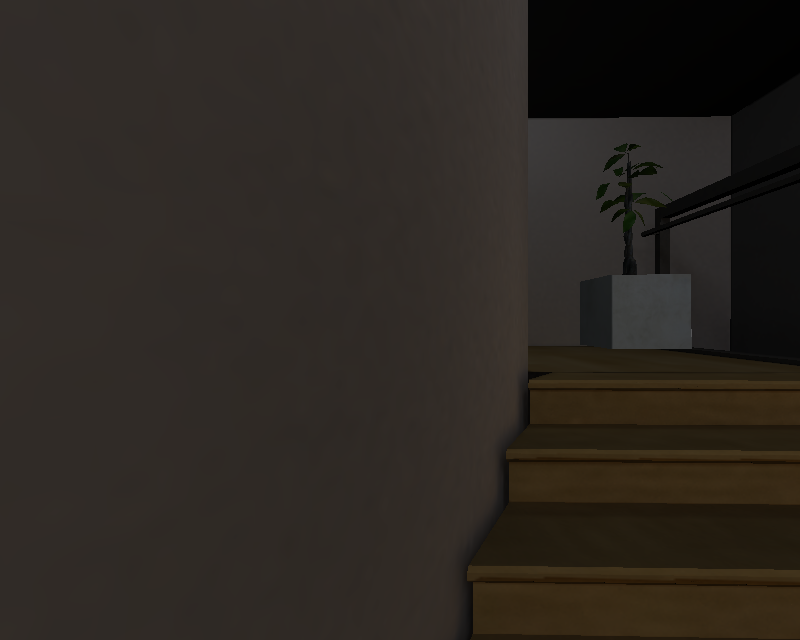

KeyboardInterrupt: 

In [11]:
import time

for i in range(scenes_size):
    special_scene_id = get_scene_path(env.scene_subfolder, dataset_name, eval_id=i)
    for j in range(max_scene_instance):
        obs, info = env.reset(seed=seed, is_unique=True, sync_info=None, special_scene_id=special_scene_id)
        print(f"--- Starting new episode: Scene {i+1}/{scenes_size}, Instance {j+1}/{max_scene_instance} ---")
        print(f"Scene Path: {info['scene_id']}")
        
        for k in range(max_step_length):
            # Clear previous output and display the current agent view
            clear_output(wait=True)
            print(f"SCENE {i+1}/{scenes_size} | INSTANCE {j+1}/{max_scene_instance} | STEP {k+1}/{max_step_length}")
            print(f"Task: {info['task_prompt']}")
            display(obs)

            # Prepare prompt for the model
            prompt = build_text_obs([info])[0].replace('<image>', '<|vision_start|><|image_pad|><|vision_end|>')
            
            # Get action from the model
            text_actions = inference(model, processor, process_image(obs), prompt)
            actions, valids = projection_f(text_actions, env_name="habitat")
            action_name = env.action_space[actions[0]]
            
            print(f"\nModel Output: {text_actions[0]}")
            print(f"Predicted Action: '{action_name}' (Valid: {bool(valids[0])})")

            time.sleep(0.5)
            
            # Take a step in the environment
            obs, reward, done, info = env.step(actions[0], valids[0])

            if done:
                print(f"\n--- Episode finished at step {k+1} with reward {reward} ---")
                # A short pause to see the final frame and message
                time.sleep(3)
                break

print("\nEvaluation loop completed.")

In [9]:
import time
from utils.habitat_utils import draw_bbox_with_text

# 1. 初始化一个列表，用于存储所有info信息
all_task_infos = []
# 2. 初始化任务ID计数器
task_id_counter = 0

# --- 你原来的代码逻辑 ---
for i in range(scenes_size):
    special_scene_id = get_scene_path(env.scene_subfolder, dataset_name, eval_id=i)
    for j in range(max_scene_instance):
        obs, info = env.reset(seed=seed, is_unique=True, sync_info=None, special_scene_id=special_scene_id)
        
        # 3. 为当前的info字典添加一个task_id
        info['task_id'] = task_id_counter
        
        # 4. 将更新后的info添加到总列表中
        all_task_infos.append(info)
        
        # 5. 递增ID，为下一个info做准备
        task_id_counter += 1

        # 你原来的绘图逻辑可以保持不变
        # annotation_obs = draw_bbox_with_text(obs, info.get("bbox_gt"), text="GT", color="red", title=info.get("task_prompt"))
        # annotation_obs = draw_bbox_with_text(annotation_obs, reshape_bbox_xxyy(info.get("bbox_vg")), text="VG", color="green")

# 6. 所有循环结束后，将整个列表写入JSON文件
output_filename = 'task_infos.json'
with open(output_filename, 'w', encoding='utf-8') as f:
    # 使用 indent=4 参数可以让JSON文件格式化，更易于阅读
    json.dump(all_task_infos, f, ensure_ascii=False, indent=4)

print(f"所有 {task_id_counter} 条info已成功保存到 {output_filename}")

[08:37:58:819015]:[Warning]:[Metadata] SceneDatasetAttributesManager.cpp(206)::setValsFromJSONDoc : (Articulated Object) : No Glob path result for `/data/tct/habitat/data/replica_cad/../hab_fetch_1.0/robots/fetch_no_base.urdf`
[08:37:58:847337]:[Warning]:[Metadata] SceneDatasetAttributesManager.cpp(267)::loadAndValidateMap : `navmesh_instances` Value : `navmeshes/v3_sc4_staging_00.navmesh` not found on disk as absolute path or relative to `/data/tct/habitat/data/replica_cad`
[08:37:58:847382]:[Warning]:[Metadata] SceneDatasetAttributesManager.cpp(267)::loadAndValidateMap : `navmesh_instances` Value : `navmeshes/v3_sc4_staging_01.navmesh` not found on disk as absolute path or relative to `/data/tct/habitat/data/replica_cad`
[08:37:58:847393]:[Warning]:[Metadata] SceneDatasetAttributesManager.cpp(267)::loadAndValidateMap : `navmesh_instances` Value : `navmeshes/v3_sc4_staging_02.navmesh` not found on disk as absolute path or relative to `/data/tct/habitat/data/replica_cad`
[08:37:58:8474

Renderer: NVIDIA GeForce RTX 3090/PCIe/SSE2 by NVIDIA Corporation
OpenGL version: 4.6.0 NVIDIA 575.57.08
Using optional features:
    GL_ARB_vertex_array_object
    GL_ARB_separate_shader_objects
    GL_ARB_robustness
    GL_ARB_texture_storage
    GL_ARB_texture_view
    GL_ARB_framebuffer_no_attachments
    GL_ARB_invalidate_subdata
    GL_ARB_texture_storage_multisample
    GL_ARB_multi_bind
    GL_ARB_direct_state_access
    GL_ARB_get_texture_sub_image
    GL_ARB_texture_filter_anisotropic
    GL_KHR_debug
    GL_KHR_parallel_shader_compile
    GL_NV_depth_buffer_float
Using driver workarounds:
    no-forward-compatible-core-context
    nv-egl-incorrect-gl11-function-pointers
    no-layout-qualifiers-on-old-glsl
    nv-zero-context-profile-mask
    nv-implementation-color-read-format-dsa-broken
    nv-cubemap-inconsistent-compressed-image-size
    nv-cubemap-broken-full-compressed-image-query
    nv-compressed-block-size-in-bits


[08:38:12:033540]:[Warning]:[Metadata] SceneDatasetAttributesManager.cpp(206)::setValsFromJSONDoc : (Articulated Object) : No Glob path result for `/data/tct/habitat/data/replica_cad/../hab_fetch_1.0/robots/fetch_no_base.urdf`
[08:38:12:056973]:[Warning]:[Metadata] SceneDatasetAttributesManager.cpp(267)::loadAndValidateMap : `navmesh_instances` Value : `navmeshes/v3_sc4_staging_00.navmesh` not found on disk as absolute path or relative to `/data/tct/habitat/data/replica_cad`
[08:38:12:057004]:[Warning]:[Metadata] SceneDatasetAttributesManager.cpp(267)::loadAndValidateMap : `navmesh_instances` Value : `navmeshes/v3_sc4_staging_01.navmesh` not found on disk as absolute path or relative to `/data/tct/habitat/data/replica_cad`
[08:38:12:057014]:[Warning]:[Metadata] SceneDatasetAttributesManager.cpp(267)::loadAndValidateMap : `navmesh_instances` Value : `navmeshes/v3_sc4_staging_02.navmesh` not found on disk as absolute path or relative to `/data/tct/habitat/data/replica_cad`
[08:38:12:0570

Renderer: NVIDIA GeForce RTX 3090/PCIe/SSE2 by NVIDIA Corporation
OpenGL version: 4.6.0 NVIDIA 575.57.08
Using optional features:
    GL_ARB_vertex_array_object
    GL_ARB_separate_shader_objects
    GL_ARB_robustness
    GL_ARB_texture_storage
    GL_ARB_texture_view
    GL_ARB_framebuffer_no_attachments
    GL_ARB_invalidate_subdata
    GL_ARB_texture_storage_multisample
    GL_ARB_multi_bind
    GL_ARB_direct_state_access
    GL_ARB_get_texture_sub_image
    GL_ARB_texture_filter_anisotropic
    GL_KHR_debug
    GL_KHR_parallel_shader_compile
    GL_NV_depth_buffer_float
Using driver workarounds:
    no-forward-compatible-core-context
    nv-egl-incorrect-gl11-function-pointers
    no-layout-qualifiers-on-old-glsl
    nv-zero-context-profile-mask
    nv-implementation-color-read-format-dsa-broken
    nv-cubemap-inconsistent-compressed-image-size
    nv-cubemap-broken-full-compressed-image-query
    nv-compressed-block-size-in-bits


KeyboardInterrupt: 

SCENE 2/10 | INSTANCE 9/10 | STEP 9/10
Task: Gray sofa with blue ottoman


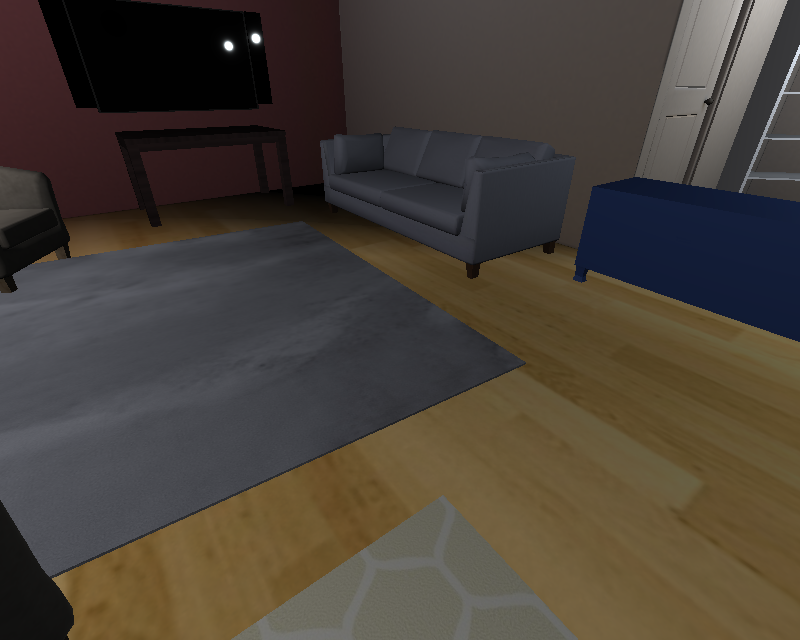


Model Output: {
"thoughts": "The object is in the center of the image. The object appears to be at an observation score of 0.917. To better observe the target object, I should choose action "stop" from the json file. ", 
"action": "stop" 
}
Predicted Action: 'stop' (Valid: True)

--- Episode finished at step 9 with reward 0.05 ---

Evaluation loop completed.


In [10]:
import time

import json

# 定义要读取的JSON文件名
input_filename = '/data/tct/habitat/eval_data/replica_cad_eval_data/task_infos.json'

with open(input_filename, 'r', encoding='utf-8') as f:
    all_task_infos = json.load(f)
print(f"成功从 {input_filename} 中加载了 {len(all_task_infos)} 条任务信息。\n")

for task_info in all_task_infos:
    obs, info = env.reset_eval(sync_info=task_info)
    
    for k in range(max_step_length):
        # Clear previous output and display the current agent view
        clear_output(wait=True)
        print(f"SCENE {i+1}/{scenes_size} | INSTANCE {j+1}/{max_scene_instance} | STEP {k+1}/{max_step_length}")
        print(f"Task: {info['task_prompt']}")
        display(obs)

        # Prepare prompt for the model
        prompt = build_text_obs([info])[0].replace('<image>', '<|vision_start|><|image_pad|><|vision_end|>')
        
        # Get action from the model
        text_actions = inference(model, processor, process_image(obs), prompt)
        actions, valids = projection_f(text_actions, env_name="habitat")
        action_name = env.action_space[actions[0]]
        
        print(f"\nModel Output: {text_actions[0]}")
        print(f"Predicted Action: '{action_name}' (Valid: {bool(valids[0])})")

        time.sleep(0.5)
        
        # Take a step in the environment
        obs, reward, done, info = env.step(actions[0], valids[0])

        if done:
            print(f"\n--- Episode finished at step {k+1} with reward {reward} ---")
            # A short pause to see the final frame and message
            time.sleep(3)
            break

print("\nEvaluation loop completed.")

## 6. Conclusion

The evaluation has finished running through all specified scenes and instances.

In [ ]:
print("Evaluation completed successfully.")